# Phân tích khám phá dữ liệu cổ phiếu VN & US

Notebook này thực hiện **một pipeline dùng chung** cho chế độ `single`, `batch` hoặc `both`:

> Nạp → Kiểm tra → Làm sạch → Tạo đặc trưng → EDA → Phân tích chân trời → Nhận xét → Xuất Excel

Mục tiêu là mô tả dữ liệu, kiểm tra các chân trời $T\in\{1,5,10,20,30\}$ phiên và chuẩn bị đầu vào đáng tin cậy cho giai đoạn ML sau. Notebook **không huấn luyện mô hình, không xếp hạng cổ phiếu và không tuyên bố T tối ưu**.

### Nguyên tắc phương pháp

- Đặc trưng tại thời điểm *t* chỉ dùng thông tin đến *t*.
- Lợi nhuận/nhãn tương lai dùng `Adj Close`; không trộn giá điều chỉnh và chưa điều chỉnh.
- Dữ liệu quyết định mặc định chỉ dùng tập Train. Validation và Test được giữ kín cho giai đoạn ML.
- Với US, lịch XNYS từ `exchange_calendars` được dùng để xác minh phiên. Với VN, gói hiện tại không có lịch HOSE đáng tin cậy: lịch ngày làm việc chỉ là phép kiểm tra bảo thủ; các khoảng chứa ngày làm việc bị thiếu bị loại khỏi thống kê chân trời và được ghi rõ là chưa xác minh.
- Lợi nhuận nhiều ngày chồng lấn phụ thuộc thống kê; notebook không dùng kiểm định giả định mẫu độc lập.
- `Adj Close` là dữ liệu điều chỉnh hồi cứu, có thể không tái tạo hoàn hảo góc nhìn point-in-time tại ngày lịch sử.


In [1]:
from pathlib import Path
from dataclasses import dataclass
from io import BytesIO
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xlsxwriter
import exchange_calendars as xcals
from IPython.display import display, Image

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Tự nhận diện thư mục gốc khi chạy từ root hoặc từ notebooks/.
ROOT = Path.cwd()
if not (ROOT / "Raw Data").exists():
    ROOT = ROOT.parent

CONFIG = {
    "RUN_MODE": "both",             # "single" | "batch" | "both"
    "SELECTED_MARKET": "VN",
    "SELECTED_TICKER": "FPT",       # Có thể ghi FPT hoặc FPT.VN
    "HORIZONS": [1, 5, 10, 20, 30],
    "TRAIN_END": "2023-12-31",
    "VALIDATION_END": "2024-12-31",
    "ANALYSIS_START": "2020-01-01", # Date >= 2020-01-01
    "ANALYSIS_END": "2026-09-01",
    "FULL_SAMPLE_DESCRIPTIVE": False,
    "DROP_NONPOSITIVE_PRICES": True,
    "DROP_INVALID_OHLC": True,
    "DROP_ZERO_VOLUME_ROWS": True,  # Loại mọi quan sát không có giao dịch
    "CHART_DPI": 115,
    "EXPORT_CHARTS": True,
    "MAX_BATCH_DISPLAY_ROWS": 12,
}

RAW_DIR = ROOT / "Raw Data"
OUT_SINGLE = ROOT / "outputs" / "single"
OUT_BATCH = ROOT / "outputs" / "batch"
OUT_CHARTS = ROOT / "outputs" / "charts"
for folder in [OUT_SINGLE, OUT_BATCH, OUT_CHARTS]:
    folder.mkdir(parents=True, exist_ok=True)

assert CONFIG["RUN_MODE"] in {"single", "batch", "both"}
assert pd.Timestamp(CONFIG["TRAIN_END"]) < pd.Timestamp(CONFIG["VALIDATION_END"])
print(f"Thư mục dự án: {ROOT}")
print(f"Chế độ chạy: {CONFIG['RUN_MODE']} | Train ≤ {CONFIG['TRAIN_END']} | Validation ≤ {CONFIG['VALIDATION_END']}")

Thư mục dự án: C:\Users\DELL\projects\P4AIDS - Stock
Chế độ chạy: both | Train ≤ 2023-12-31 | Validation ≤ 2024-12-31


## 1. Khám phá tệp và kiểm tra schema

Mỗi CSV được nhận diện thị trường từ thư mục cha. Bảng dưới chỉ hiển thị tóm tắt schema; không in toàn bộ dữ liệu. Mapping cột được cấu hình để chịu được khác biệt viết hoa, dấu cách và một số tên thường gặp.


In [2]:
COLUMN_ALIASES = {
    "Date": ["date", "datetime", "timestamp", "time"],
    "Open": ["open", "openprice", "priceopen"],
    "High": ["high", "highprice", "pricehigh"],
    "Low": ["low", "lowprice", "pricelow"],
    "Close": ["close", "closeprice", "priceclose"],
    "Adj Close": ["adjclose", "adjustedclose", "closeadjusted", "adj_close"],
    "Volume": ["volume", "vol"],
    "Dividends": ["dividends", "dividend"],
    "Stock Splits": ["stocksplits", "stocksplit", "splits", "split"],
}
REQUIRED = ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
NUMERIC = ["Open", "High", "Low", "Close", "Adj Close", "Volume", "Dividends", "Stock Splits"]

def _canon(text):
    return re.sub(r"[^a-z0-9]", "", str(text).lower())

def map_columns(columns):
    lookup = {_canon(c): c for c in columns}
    rename = {}
    for standard, aliases in COLUMN_ALIASES.items():
        candidates = [_canon(standard)] + [_canon(x) for x in aliases]
        found = next((lookup[c] for c in candidates if c in lookup), None)
        if found is not None:
            rename[found] = standard
    return rename

def discover_files(raw_dir=RAW_DIR):
    rows = []
    for path in sorted(raw_dir.rglob("*.csv")):
        parts_upper = [p.upper() for p in path.parts]
        market = "VN" if "VN" in parts_upper else "US" if "US" in parts_upper else "UNKNOWN"
        ticker = path.stem.upper().replace(".VN", "")
        rows.append({"path": path, "market": market, "ticker": ticker, "file": path.name})
    return pd.DataFrame(rows)

def schema_profile(files):
    out = []
    for r in files.itertuples(index=False):
        try:
            sample = pd.read_csv(r.path, nrows=5)
            mapping = map_columns(sample.columns)
            out.append({
                "Thị trường": r.market, "Mã": r.ticker, "Tệp": r.file,
                "Số cột": len(sample.columns), "Cột gốc": ", ".join(sample.columns),
                "Cột chuẩn nhận diện": ", ".join(mapping.values()),
                "Thiếu cột bắt buộc": ", ".join(c for c in REQUIRED if c not in mapping.values()) or "Không",
                "Trạng thái": "OK" if all(c in mapping.values() for c in REQUIRED) else "LỖI SCHEMA",
            })
        except Exception as exc:
            out.append({"Thị trường": r.market, "Mã": r.ticker, "Tệp": r.file, "Trạng thái": f"LỖI: {exc}"})
    return pd.DataFrame(out)

FILES = discover_files()
SCHEMA_PROFILE = schema_profile(FILES)
display(FILES.groupby("market").size().rename("Số tệp").to_frame())
display(SCHEMA_PROFILE.head(8))
print("Schema duy nhất:", SCHEMA_PROFILE["Cột gốc"].nunique(dropna=True), "| Tệp lỗi schema:", (SCHEMA_PROFILE["Trạng thái"] != "OK").sum())

,Số tệp
market,
US,20
VN,30


,Thị trường,Mã,Tệp,Số cột,Cột gốc,Cột chuẩn nhận diện,Thiếu cột bắt buộc,Trạng thái
0,US,AAPL,AAPL.csv,9,"Date, Open, High, Low, Close, Adj Close, Volum...","Date, Open, High, Low, Close, Adj Close, Volum...",Không,OK
1,US,ADBE,ADBE.csv,9,"Date, Open, High, Low, Close, Adj Close, Volum...","Date, Open, High, Low, Close, Adj Close, Volum...",Không,OK
2,US,AMD,AMD.csv,9,"Date, Open, High, Low, Close, Adj Close, Volum...","Date, Open, High, Low, Close, Adj Close, Volum...",Không,OK
3,US,AMGN,AMGN.csv,9,"Date, Open, High, Low, Close, Adj Close, Volum...","Date, Open, High, Low, Close, Adj Close, Volum...",Không,OK
4,US,AMZN,AMZN.csv,9,"Date, Open, High, Low, Close, Adj Close, Volum...","Date, Open, High, Low, Close, Adj Close, Volum...",Không,OK
5,US,AVGO,AVGO.csv,9,"Date, Open, High, Low, Close, Adj Close, Volum...","Date, Open, High, Low, Close, Adj Close, Volum...",Không,OK
6,US,COST,COST.csv,9,"Date, Open, High, Low, Close, Adj Close, Volum...","Date, Open, High, Low, Close, Adj Close, Volum...",Không,OK
7,US,CSCO,CSCO.csv,9,"Date, Open, High, Low, Close, Adj Close, Volum...","Date, Open, High, Low, Close, Adj Close, Volum...",Không,OK


Schema duy nhất: 1 | Tệp lỗi schema: 0


## 2. Hàm nạp, làm sạch và kiểm soát chất lượng

Các quyết định làm sạch đều được ghi vào `cleaning_log`. Notebook không forward-fill giá, không thay Volume 0 bằng trung bình và không tạo quan sát giả. Dòng giá/OHLC không hợp lệ bị loại. Toàn bộ dòng `Volume = 0` bị loại khỏi tập phân tích theo chính sách chất lượng dữ liệu vì không đại diện cho một quan sát giao dịch có thanh khoản. OHLC phẳng vẫn được thống kê để audit, nhưng notebook **không** tự động kết luận nguyên nhân là ngày nghỉ, đình chỉ hay lỗi nguồn.


In [3]:
def parse_local_dates(series):
    # Lấy phần ngày trước timezone để không làm lệch ngày địa phương VN/US.
    text = series.astype("string").str.strip().str.slice(0, 10)
    return pd.to_datetime(text, errors="coerce")

def split_name(dates):
    dates = pd.to_datetime(dates)
    return np.select(
        [dates <= pd.Timestamp(CONFIG["TRAIN_END"]), dates <= pd.Timestamp(CONFIG["VALIDATION_END"])],
        ["Train", "Validation"], default="Test"
    )

def expected_sessions(market, start, end):
    if market == "US":
        cal = xcals.get_calendar("XNYS")
        sessions = cal.sessions_in_range(pd.Timestamp(start), pd.Timestamp(end))
        sessions = pd.DatetimeIndex(sessions).tz_localize(None).normalize()
        return sessions, "XNYS authoritative (exchange_calendars)"
    # Không gọi đây là lịch HOSE; chỉ là bộ lọc bảo thủ khi chưa có lịch chính thức.
    return pd.bdate_range(start, end).normalize(), "Ngày làm việc Mon-Fri, CHƯA xác minh lịch HOSE"

def load_and_clean(path, market, ticker):
    raw = pd.read_csv(path)
    original_columns = list(raw.columns)
    raw = raw.rename(columns=map_columns(raw.columns))
    missing_required = [c for c in REQUIRED if c not in raw.columns]
    if missing_required:
        raise ValueError(f"Thiếu cột bắt buộc: {missing_required}")
    for optional in ["Dividends", "Stock Splits"]:
        if optional not in raw.columns:
            raw[optional] = 0.0

    audit = {
        "Thị trường": market, "Mã": ticker, "Tệp": Path(path).name,
        "Số dòng gốc": len(raw), "Số cột gốc": len(original_columns),
        "Ngày không hợp lệ": 0, "Ngày trùng": 0, "Ô thiếu gốc": int(raw.isna().sum().sum()),
        "Giá không dương": 0, "OHLC không hợp lệ": 0,
        "Volume = 0": 0, "Volume < 0": 0,
        "Zero-volume rows đã loại": 0,
        "Zero-volume & OHLC phẳng": 0,
        "Zero-volume & OHLC biến động": 0,
        "Dòng đã loại": 0, "Dòng sạch": 0,
        "Sự kiện cổ tức": 0, "Sự kiện split": 0,
        "Vấn đề chưa giải quyết": "",
    }
    logs = []
    raw["Date"] = parse_local_dates(raw["Date"])
    audit["Ngày không hợp lệ"] = int(raw["Date"].isna().sum())
    if audit["Ngày không hợp lệ"]:
        logs.append({"Hành động": "Loại", "Lý do": "Ngày không parse được", "Số dòng": audit["Ngày không hợp lệ"]})

    for c in NUMERIC:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
    audit["Ngày trùng"] = int(raw["Date"].notna().sum() - raw.loc[raw["Date"].notna(), "Date"].nunique())
    if audit["Ngày trùng"]:
        logs.append({"Hành động": "Loại", "Lý do": "Ngày trùng; giữ bản ghi cuối", "Số dòng": audit["Ngày trùng"]})
    raw = raw.sort_values("Date", kind="stable").drop_duplicates("Date", keep="last")

    prices = raw[["Open", "High", "Low", "Close", "Adj Close"]]
    nonpositive = prices.isna().any(axis=1) | (prices <= 0).any(axis=1)
    invalid_ohlc = (
        (raw["High"] < raw[["Open", "Close", "Low"]].max(axis=1)) |
        (raw["Low"] > raw[["Open", "Close", "High"]].min(axis=1))
    )
    flat_ohlc = raw[["Open", "High", "Low", "Close"]].nunique(axis=1, dropna=False).eq(1)
    zero_volume = raw["Volume"].eq(0)
    negative_volume = raw["Volume"].lt(0) | raw["Volume"].isna()
    zero_flat = zero_volume & flat_ohlc
    zero_nonflat = zero_volume & ~flat_ohlc

    audit["Giá không dương"] = int(nonpositive.sum())
    audit["OHLC không hợp lệ"] = int(invalid_ohlc.sum())
    audit["Volume = 0"] = int(zero_volume.sum())
    audit["Volume < 0"] = int(raw["Volume"].lt(0).sum())
    audit["Zero-volume rows đã loại"] = int(zero_volume.sum()) if CONFIG["DROP_ZERO_VOLUME_ROWS"] else 0
    audit["Zero-volume & OHLC phẳng"] = int(zero_flat.sum())
    audit["Zero-volume & OHLC biến động"] = int(zero_nonflat.sum())
    audit["Sự kiện cổ tức"] = int(raw["Dividends"].fillna(0).ne(0).sum())
    audit["Sự kiện split"] = int(raw["Stock Splits"].fillna(0).ne(0).sum())

    remove = raw["Date"].isna() | negative_volume
    if CONFIG["DROP_NONPOSITIVE_PRICES"]:
        remove |= nonpositive
    if CONFIG["DROP_INVALID_OHLC"]:
        remove |= invalid_ohlc
    if CONFIG["DROP_ZERO_VOLUME_ROWS"]:
        remove |= zero_volume
    for reason, count in [
        ("Giá thiếu/không dương", int(nonpositive.sum())),
        ("Quan hệ OHLC không hợp lệ", int(invalid_ohlc.sum())),
        ("Volume thiếu/âm", int(negative_volume.sum())),
        ("Volume=0: loại khỏi tập phân tích theo chính sách chất lượng dữ liệu; không suy luận là ngày nghỉ chính thức", int(zero_volume.sum())),
    ]:
        if count:
            logs.append({"Hành động": "Loại/đánh giá theo chính sách", "Lý do": reason, "Số dòng": count})

    clean = raw.loc[~remove].copy().sort_values("Date").reset_index(drop=True)
    if CONFIG["ANALYSIS_START"]:
        clean = clean[clean["Date"] >= pd.Timestamp(CONFIG["ANALYSIS_START"])].copy()
    if CONFIG["ANALYSIS_END"]:
        clean = clean[clean["Date"] <= pd.Timestamp(CONFIG["ANALYSIS_END"])].copy()
    clean["ZeroVolumeUnresolved"] = clean["Volume"].eq(0)
    clean["Split"] = split_name(clean["Date"])
    audit["Dòng sạch"] = len(clean)
    audit["Dòng đã loại"] = len(raw) - len(clean)

    unresolved = []
    if market == "VN":
        unresolved.append("Chưa có lịch HOSE chính thức; khoảng chân trời qua ngày làm việc bị thiếu được loại bảo thủ")
    unresolved.append("Quy ước điều chỉnh Adj Close suy ra từ nguồn CSV, chưa xác minh độc lập point-in-time")
    audit["Vấn đề chưa giải quyết"] = "; ".join(unresolved)
    logs.append({"Hành động": "Giữ", "Lý do": "Dòng sạch sau kiểm tra", "Số dòng": len(clean)})
    return clean, pd.DataFrame([audit]), pd.DataFrame(logs)

def verify_adjustment(df):
    ratio = df["Adj Close"] / df["Close"]
    valid = ratio.replace([np.inf, -np.inf], np.nan).dropna()
    return {
        "Nguồn lợi nhuận": "Adj Close",
        "Tỷ lệ Adj/Close min": valid.min() if len(valid) else np.nan,
        "Tỷ lệ Adj/Close max": valid.max() if len(valid) else np.nan,
        "Có khác biệt điều chỉnh": bool((valid.sub(1).abs() > 1e-8).any()) if len(valid) else False,
        "Quy ước": "Dùng nhất quán Adj Close cho lợi nhuận và nhãn; không trộn Close",
        "Hạn chế": "Điều chỉnh hồi cứu; không bảo đảm dữ liệu point-in-time",
    }

## 3. Đặc trưng chỉ dùng thông tin quá khứ

Các đặc trưng chính:

- **Return:** $r_t=P_t/P_{t-1}-1$, lợi nhuận 5/10/20 phiên và lợi nhuận tích lũy.
- **Trend:** MA5/20/50 và tỷ lệ giá/MA trừ 1.
- **Momentum:** $P_t/P_{t-k}-1$ với $k=5,10,20$; RSI14 theo trung bình lăn của tăng/giảm.
- **Volatility:** độ lệch chuẩn lăn của lợi nhuận ngày, annualize bằng $\sqrt{252}$.
- **Volume:** MA20 và relative volume = Volume/MA20.
- **Risk:** drawdown từ đỉnh lịch sử, maximum drawdown và downside volatility.

`rolling(..., min_periods=window)` khiến đầu chuỗi là NaN đúng theo lookback; không điền giả.


In [4]:
FEATURE_GROUPS = {
    "Lợi nhuận": ["Return_1", "Return_5", "Return_10", "Return_20", "Cumulative_Return"],
    "Xu hướng": ["Adj Close", "MA5", "MA20", "MA50", "Price_to_MA20"],
    "Động lượng": ["Momentum_5", "Momentum_10", "Momentum_20", "RSI14"],
    "Biến động": ["Volatility_5", "Volatility_10", "Volatility_20", "Volatility_60"],
    "Khối lượng": ["Volume", "Volume_MA20", "Relative_Volume"],
    "Rủi ro": ["Drawdown", "Downside_Return"],
}
UNITS = {
    "Adj Close": "đơn vị giá", "MA5": "đơn vị giá", "MA20": "đơn vị giá", "MA50": "đơn vị giá",
    "Volume": "cổ phiếu", "Volume_MA20": "cổ phiếu", "RSI14": "điểm", "Relative_Volume": "lần",
}

def engineer_features(df):
    d = df.copy()
    p = d["Adj Close"]
    d["Return_1"] = p.pct_change(fill_method=None)
    for w in [5, 10, 20]:
        d[f"Return_{w}"] = p.pct_change(w, fill_method=None)
    first = p.iloc[0] if len(p) else np.nan
    d["Cumulative_Return"] = p / first - 1
    for w in [5, 20, 50]:
        d[f"MA{w}"] = p.rolling(w, min_periods=w).mean()
    d["Price_to_MA20"] = p / d["MA20"] - 1
    for w in [5, 10, 20]:
        d[f"Momentum_{w}"] = p / p.shift(w) - 1
    delta = p.diff()
    avg_gain = delta.clip(lower=0).rolling(14, min_periods=14).mean()
    avg_loss = -delta.clip(upper=0).rolling(14, min_periods=14).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    d["RSI14"] = 100 - 100 / (1 + rs)
    for w in [5, 10, 20, 60]:
        d[f"Volatility_{w}"] = d["Return_1"].rolling(w, min_periods=w).std(ddof=1) * np.sqrt(252)
    d["Volume_MA20"] = d["Volume"].rolling(20, min_periods=20).mean()
    d["Relative_Volume"] = d["Volume"] / d["Volume_MA20"].replace(0, np.nan)
    d["Running_Max"] = p.cummax()
    d["Drawdown"] = p / d["Running_Max"] - 1
    d["Downside_Return"] = d["Return_1"].where(d["Return_1"] < 0)
    d["Range_Pct"] = (d["High"] - d["Low"]) / d["Close"].replace(0, np.nan)
    return d

def add_horizon_targets(df, market, horizons):
    d = df.copy()
    if d.empty:
        for t in horizons:
            d[f"FutureReturn_{t}"] = np.nan
            d[f"Target_{t}"] = pd.Series(dtype="Float64")
            d[f"HorizonEligible_{t}"] = False
        return d, "Không đủ dữ liệu"
    sessions, calendar_note = expected_sessions(market, d["Date"].min(), d["Date"].max())
    pos = pd.Series(np.arange(len(sessions)), index=sessions)
    current_pos = d["Date"].map(pos)
    for t in horizons:
        future_price = d["Adj Close"].shift(-t)
        future_date = d["Date"].shift(-t)
        future_pos = future_date.map(pos)
        consecutive = (future_pos - current_pos).eq(t)
        same_split = d["Split"].shift(-t).eq(d["Split"])
        eligible = consecutive & same_split & future_price.notna()
        ret = (future_price / d["Adj Close"] - 1).where(eligible)
        d[f"FutureReturn_{t}"] = ret
        d[f"Target_{t}"] = pd.Series(np.where(ret.notna(), (ret > 0).astype(float), np.nan), index=d.index)
        d[f"HorizonEligible_{t}"] = eligible
        d[f"EndpointDate_{t}"] = future_date.where(eligible)
    return d, calendar_note

def scope_data(df):
    if CONFIG["FULL_SAMPLE_DESCRIPTIVE"]:
        return df.copy(), "Toàn mẫu — chỉ mô tả, không dùng để chọn đặc trưng/T"
    return df[df["Split"].eq("Train")].copy(), "Train — dùng cho EDA quyết định"

def descriptive_stats(df):
    rows = []
    for group, features in FEATURE_GROUPS.items():
        for feature in features:
            s = pd.to_numeric(df.get(feature), errors="coerce").dropna()
            unit = UNITS.get(feature, "%" if any(k in feature for k in ["Return", "Momentum", "Volatility", "Drawdown", "Price_to"]) else "tỷ lệ")
            rows.append({
                "Nhóm": group, "Chỉ tiêu": feature, "Đơn vị": unit, "N": len(s),
                "Trung bình": s.mean() if len(s) else np.nan,
                "Trung vị": s.median() if len(s) else np.nan,
                "Độ lệch chuẩn": s.std(ddof=1) if len(s) > 1 else np.nan,
                "Q05": s.quantile(.05) if len(s) else np.nan, "Q25": s.quantile(.25) if len(s) else np.nan,
                "Q75": s.quantile(.75) if len(s) else np.nan, "Q95": s.quantile(.95) if len(s) else np.nan,
                "Min": s.min() if len(s) else np.nan, "Max": s.max() if len(s) else np.nan,
            })
    return pd.DataFrame(rows)

def horizon_statistics(df, horizons):
    rows, stability = [], []
    for t in horizons:
        s = df[f"FutureReturn_{t}"].dropna()
        downs = s[s <= 0]
        rows.append({
            "T": t, "N hợp lệ": len(s), "Trung bình": s.mean() if len(s) else np.nan,
            "Trung vị": s.median() if len(s) else np.nan,
            "Độ lệch chuẩn": s.std(ddof=1) if len(s) > 1 else np.nan,
            "Q05": s.quantile(.05) if len(s) else np.nan, "Q25": s.quantile(.25) if len(s) else np.nan,
            "Q75": s.quantile(.75) if len(s) else np.nan, "Q95": s.quantile(.95) if len(s) else np.nan,
            "P(UP)": (s > 0).mean() if len(s) else np.nan,
            "P(DOWN)": (s <= 0).mean() if len(s) else np.nan,
            "Downside mean": downs.mean() if len(downs) else np.nan,
            "Downside std": downs.std(ddof=1) if len(downs) > 1 else np.nan,
        })
        temp = df.loc[s.index, ["Date"]].copy()
        temp["ret"] = s
        temp["Giai đoạn"] = temp["Date"].dt.year.astype(str)
        for period, g in temp.groupby("Giai đoạn"):
            stability.append({"T": t, "Giai đoạn": period, "N": len(g), "Mean": g["ret"].mean(), "P(UP)": (g["ret"] > 0).mean(), "Std": g["ret"].std(ddof=1)})
    return pd.DataFrame(rows), pd.DataFrame(stability)

def maximum_drawdown(df):
    s = df["Drawdown"].dropna()
    return s.min() if len(s) else np.nan

def downside_volatility(df):
    s = df.loc[df["Return_1"] < 0, "Return_1"].dropna()
    return s.std(ddof=1) * np.sqrt(252) if len(s) > 1 else np.nan

## 4. Nhận xét tự động dựa trên quy tắc

Nhận xét dùng đúng các đối tượng kết quả cho cả single và batch. Mỗi câu nêu quan sát và giới hạn/hàm ý; không dùng API LLM và không hardcode kết luận về T.


In [5]:
def _pct(x):
    return "không đủ dữ liệu" if pd.isna(x) else f"{x:.2%}"

def generate_insights(result):
    q = result["quality"].iloc[0]
    d = result["scope_df"]
    h = result["horizon"]
    insights = []
    insights.append({"Nhóm": "Chất lượng dữ liệu", "Nhận xét":
        f"Từ {int(q['Số dòng gốc']):,} dòng, giữ {int(q['Dòng sạch']):,} dòng; loại {int(q['Dòng đã loại']):,}. "
        f"Có {int(q['Volume = 0']):,} dòng Volume=0; toàn bộ bị loại khỏi tập phân tích theo chính sách chất lượng dữ liệu. "
        f"Việc loại không đồng nghĩa các dòng này đều là ngày sàn đóng cửa. Hạn chế: {q['Vấn đề chưa giải quyết']}"})
    if d.empty:
        for group in FEATURE_GROUPS:
            insights.append({"Nhóm": group, "Nhận xét": "Không đủ quan sát trong phạm vi Train để kết luận; cần dữ liệu lịch sử dài hơn."})
    else:
        r = d["Return_1"].dropna()
        insights.append({"Nhóm": "Lợi nhuận", "Nhận xét":
            f"Lợi nhuận ngày trung bình {_pct(r.mean())}, trung vị {_pct(r.median())}; Q05={_pct(r.quantile(.05))} và Q95={_pct(r.quantile(.95))}. Đây là mô tả lịch sử, không phải kỳ vọng tương lai." if len(r) else "Không đủ lợi nhuận ngày hợp lệ."})
        above = (d["Price_to_MA20"] > 0).mean() if d["Price_to_MA20"].notna().any() else np.nan
        insights.append({"Nhóm": "Xu hướng", "Nhận xét": f"Giá điều chỉnh nằm trên MA20 trong {_pct(above)} số phiên đủ lookback. MA là chỉ báo trễ và không hàm ý quan hệ nhân quả."})
        mom = d["Momentum_20"].dropna()
        insights.append({"Nhóm": "Động lượng", "Nhận xét": f"Momentum 20 phiên có trung vị {_pct(mom.median()) if len(mom) else 'không đủ dữ liệu'}. Tín hiệu có thể đảo chiều và cần đánh giá ngoài mẫu."})
        vol = d["Volatility_20"].dropna()
        insights.append({"Nhóm": "Biến động", "Nhận xét": f"Volatility 20 phiên annualized trung vị {_pct(vol.median()) if len(vol) else 'không đủ dữ liệu'}. So sánh các T phải xét khác biệt thời gian nắm giữ và lợi nhuận chồng lấn."})
        rv = d["Relative_Volume"].dropna()
        insights.append({"Nhóm": "Khối lượng", "Nhận xét": f"Relative Volume trung vị {rv.median():.2f} lần MA20." if len(rv) else "Không đủ 20 phiên để ước lượng Relative Volume."})
        insights.append({"Nhóm": "Rủi ro", "Nhận xét": f"Maximum drawdown trong phạm vi phân tích là {_pct(maximum_drawdown(d))}; downside volatility annualized là {_pct(downside_volatility(d))}. Drawdown phụ thuộc điểm bắt đầu và độ dài mẫu."})
    valid_h = h[h["N hợp lệ"] > 0]
    if valid_h.empty:
        h_text = "Không có đủ nhãn chân trời hợp lệ trong Train; không thể so sánh T. Không chọn T từ EDA."
    else:
        h_text = (f"N hợp lệ theo T nằm trong [{int(valid_h['N hợp lệ'].min()):,}, {int(valid_h['N hợp lệ'].max()):,}], "
                  f"P(UP) trong [{_pct(valid_h['P(UP)'].min())}, {_pct(valid_h['P(UP)'].max())}]. "
                  "Lợi nhuận nhiều phiên chồng lấn nên phụ thuộc thống kê; đây chỉ là bằng chứng mô tả. Không chọn T tối ưu nếu chưa đánh giá ML trên Validation và Test đã purge.")
    insights.append({"Nhóm": "Chân trời dự báo", "Nhận xét": h_text})
    return pd.DataFrame(insights)

def limitations(result):
    return pd.DataFrame({"Hạn chế / ghi chú": [
        result["calendar_note"],
        "Adj Close được dùng nhất quán nhưng là điều chỉnh hồi cứu; có rủi ro không point-in-time.",
        "Lợi nhuận T>1 chồng lấn và phụ thuộc; không dùng kiểm định mẫu độc lập.",
        "Các nhãn có endpoint vượt biên Train/Validation/Test đã bị purge theo T.",
        "Validation dành cho chọn mô hình/chân trời sau này; Test giữ kín cho đánh giá cuối.",
        "EDA không tuyên bố T tối ưu; VN là thị trường chính, US chỉ mang tính đối chiếu.",
    ]})

## 5. Biểu đồ dùng chung và đối tượng kết quả

Mỗi mã có sáu hình: giá/xu hướng, lợi nhuận & phân phối, drawdown, khối lượng, so sánh chân trời và ổn định P(UP) theo năm. Hình được tạo một lần từ `result` rồi tái sử dụng khi xuất Excel.


In [6]:
def save_figure(fig, market, ticker, key):
    path = OUT_CHARTS / f"{market}_{ticker}_{key}.png"
    fig.savefig(path, dpi=CONFIG["CHART_DPI"], bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path

def create_charts(result):
    d = result["scope_df"]
    market, ticker = result["market"], result["ticker"]
    paths = {}
    if d.empty:
        return paths

    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(d["Date"], d["Adj Close"], label="Giá điều chỉnh", lw=1.4)
    for w in [20, 50]:
        ax.plot(d["Date"], d[f"MA{w}"], label=f"MA{w}", lw=1)
    ax.set(title=f"{market}-{ticker}: Giá và xu hướng ({result['scope_label']})", ylabel="Giá điều chỉnh")
    ax.legend(ncol=3); paths["01_gia_xu_huong"] = save_figure(fig, market, ticker, "01_gia_xu_huong")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    axes[0].plot(d["Date"], d["Cumulative_Return"] * 100, color="#1976D2")
    axes[0].set(title="Lợi nhuận tích lũy", ylabel="%")
    ret = d["Return_1"].dropna() * 100
    axes[1].hist(ret, bins=45, color="#42A5F5", alpha=.85, edgecolor="white")
    axes[1].axvline(ret.median() if len(ret) else 0, color="black", ls="--", lw=1, label="Trung vị")
    axes[1].set(title="Phân phối lợi nhuận ngày", xlabel="%", ylabel="Số phiên"); axes[1].legend()
    fig.tight_layout(); paths["02_loi_nhuan"] = save_figure(fig, market, ticker, "02_loi_nhuan")

    fig, ax = plt.subplots(figsize=(10, 3.7))
    ax.fill_between(d["Date"], d["Drawdown"] * 100, 0, color="#D32F2F", alpha=.55)
    ax.set(title=f"Drawdown — MDD {_pct(maximum_drawdown(d))}", ylabel="%", xlabel="Ngày")
    paths["03_drawdown"] = save_figure(fig, market, ticker, "03_drawdown")

    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    axes[0].plot(d["Date"], d["Volume"], color="#546E7A", lw=.8, label="Volume")
    axes[0].plot(d["Date"], d["Volume_MA20"], color="#EF6C00", lw=1, label="MA20")
    axes[0].set(ylabel="Cổ phiếu", title="Khối lượng"); axes[0].legend()
    axes[1].plot(d["Date"], d["Relative_Volume"], color="#7B1FA2", lw=.8)
    axes[1].axhline(1, color="black", ls="--", lw=.8); axes[1].set(ylabel="Lần MA20", title="Relative Volume")
    fig.tight_layout(); paths["04_khoi_luong"] = save_figure(fig, market, ticker, "04_khoi_luong")

    h = result["horizon"]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
    axes[0].bar(h["T"].astype(str), h["P(UP)"] * 100, color="#2E7D32")
    axes[0].axhline(50, color="black", ls="--", lw=.8); axes[0].set(title="Tỷ lệ UP theo T", xlabel="T (phiên)", ylabel="%")
    axes[1].bar(h["T"].astype(str), h["Độ lệch chuẩn"] * 100, color="#F9A825")
    axes[1].set(title="Phân tán lợi nhuận theo T", xlabel="T (phiên)", ylabel="%")
    fig.suptitle("So sánh chân trời — mô tả, không phải lựa chọn T")
    fig.tight_layout(); paths["05_chan_troi"] = save_figure(fig, market, ticker, "05_chan_troi")

    st = result["stability"]
    if not st.empty:
        pivot = st.pivot(index="T", columns="Giai đoạn", values="P(UP)")
        fig, ax = plt.subplots(figsize=(10, 3.8))
        im = ax.imshow(pivot.values * 100, aspect="auto", cmap="RdYlGn", vmin=35, vmax=65)
        ax.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
        ax.set_yticks(range(len(pivot.index)), pivot.index)
        ax.set(xlabel="Năm", ylabel="T (phiên)", title="Ổn định thời gian của P(UP) (%)")
        fig.colorbar(im, ax=ax, label="P(UP) %")
        fig.tight_layout(); paths["06_on_dinh"] = save_figure(fig, market, ticker, "06_on_dinh")
    return paths

def analyze_file(path, market, ticker, make_charts=True):
    clean, quality, cleaning_log = load_and_clean(path, market, ticker)
    featured = engineer_features(clean)
    featured, calendar_note = add_horizon_targets(featured, market, CONFIG["HORIZONS"])
    scoped, scope_label = scope_data(featured)
    eda = descriptive_stats(scoped)
    horizon, stability = horizon_statistics(scoped, CONFIG["HORIZONS"])
    result = {
        "market": market, "ticker": ticker, "path": Path(path), "data": featured,
        "scope_df": scoped, "scope_label": scope_label, "quality": quality,
        "cleaning_log": cleaning_log, "adjustment": pd.DataFrame([verify_adjustment(featured)]),
        "eda": eda, "horizon": horizon, "stability": stability,
        "calendar_note": calendar_note,
    }
    result["insights"] = generate_insights(result)
    result["limitations"] = limitations(result)
    result["charts"] = create_charts(result) if make_charts and CONFIG["EXPORT_CHARTS"] else {}
    return result

## 6. Xuất Excel chuyên nghiệp

`write_company_sheet` là hàm duy nhất tạo nội dung sheet công ty, vì vậy báo cáo single và sheet tương ứng trong batch có cùng số liệu, insight và dữ liệu biểu đồ. Export không tính toán lại phân tích.


In [7]:
def safe_sheet_name(name, used=None):
    clean = re.sub(r"[\[\]:*?/\\]", "_", name)[:31] or "Sheet"
    if used is None:
        return clean
    base, candidate, i = clean, clean, 1
    while candidate.lower() in used:
        suffix = f"_{i}"
        candidate = base[:31-len(suffix)] + suffix
        i += 1
    used.add(candidate.lower())
    return candidate

def excel_formats(workbook):
    return {
        "title": workbook.add_format({"bold": True, "font_size": 16, "font_color": "#FFFFFF", "bg_color": "#17365D", "align": "left", "valign": "vcenter"}),
        "section": workbook.add_format({"bold": True, "font_size": 11, "font_color": "#FFFFFF", "bg_color": "#1F4E78", "border": 1}),
        "header": workbook.add_format({"bold": True, "font_color": "#FFFFFF", "bg_color": "#5B9BD5", "border": 1, "text_wrap": True, "align": "center"}),
        "text": workbook.add_format({"border": 1, "valign": "top", "text_wrap": True}),
        "number": workbook.add_format({"border": 1, "num_format": "0.0000"}),
        "percent": workbook.add_format({"border": 1, "num_format": "0.00%"}),
        "integer": workbook.add_format({"border": 1, "num_format": "#,##0"}),
        "note": workbook.add_format({"italic": True, "font_color": "#666666", "text_wrap": True, "valign": "top"}),
    }

def write_dataframe(ws, df, startrow, startcol, fmts, index=False):
    frame = df.reset_index() if index else df.copy()
    for j, col in enumerate(frame.columns):
        ws.write(startrow, startcol + j, str(col), fmts["header"])
    for i, row in enumerate(frame.itertuples(index=False, name=None), start=1):
        for j, value in enumerate(row):
            if pd.isna(value):
                ws.write_blank(startrow + i, startcol + j, None, fmts["text"])
            elif isinstance(value, (pd.Timestamp, np.datetime64)):
                ws.write(startrow + i, startcol + j, pd.Timestamp(value).strftime("%Y-%m-%d"), fmts["text"])
            elif isinstance(value, (bool, np.bool_)):
                ws.write_boolean(startrow + i, startcol + j, bool(value), fmts["text"])
            elif isinstance(value, (int, np.integer)):
                ws.write_number(startrow + i, startcol + j, int(value), fmts["integer"])
            elif isinstance(value, (float, np.floating)):
                col_name = str(frame.columns[j])
                if "Đơn vị" in frame.columns:
                    unit = str(frame.iloc[i - 1]["Đơn vị"])
                    fmt = fmts["percent"] if unit == "%" else fmts["integer"] if unit == "cổ phiếu" else fmts["number"]
                else:
                    fmt = fmts["percent"] if any(x in col_name for x in ["P(", "Mean", "Trung", "Q0", "Q2", "Q7", "Q9", "std", "Std", "Downside", "Min", "Max"]) else fmts["number"]
                ws.write_number(startrow + i, startcol + j, float(value), fmt)
            else:
                ws.write(startrow + i, startcol + j, str(value), fmts["text"])
    return startrow + len(frame) + 2

def write_section(ws, row, title, fmts, width=11):
    ws.merge_range(row, 0, row, width, title, fmts["section"])
    return row + 1

def write_company_sheet(writer, sheet_name, result, fmts):
    wb = writer.book
    ws = wb.add_worksheet(sheet_name)
    writer.sheets[sheet_name] = ws
    ws.hide_gridlines(2); ws.freeze_panes(3, 0)
    ws.set_column("A:A", 20); ws.set_column("B:B", 24); ws.set_column("C:L", 15); ws.set_column("M:V", 13)
    ws.set_row(0, 25)
    ws.merge_range("A1:L1", f"BÁO CÁO EDA — {result['market']} {result['ticker']}", fmts["title"])
    ws.write("A2", "Phạm vi EDA", fmts["header"]); ws.write("B2", result["scope_label"], fmts["text"])
    ws.write("D2", "Nguồn", fmts["header"]); ws.write("E2", result["path"].name, fmts["text"])
    ws.write("G2", "Lịch phiên", fmts["header"]); ws.merge_range("H2:L2", result["calendar_note"], fmts["text"])
    row = 3
    row = write_section(ws, row, "THÔNG TIN & CHẤT LƯỢNG DỮ LIỆU", fmts)
    row = write_dataframe(ws, result["quality"], row, 0, fmts)
    row = write_section(ws, row, "KIỂM TRA ADJ CLOSE", fmts)
    row = write_dataframe(ws, result["adjustment"], row, 0, fmts)
    row = write_section(ws, row, "NHẬT KÝ LÀM SẠCH", fmts)
    row = write_dataframe(ws, result["cleaning_log"], row, 0, fmts)
    row = write_section(ws, row, "SÁU NHÓM EDA — THỐNG KÊ", fmts)
    row = write_dataframe(ws, result["eda"], row, 0, fmts)
    row = write_section(ws, row, "SO SÁNH CHÂN TRỜI (TRAIN, ĐÃ PURGE BIÊN)", fmts)
    row = write_dataframe(ws, result["horizon"], row, 0, fmts)
    row = write_section(ws, row, "ỔN ĐỊNH THEO THỜI GIAN", fmts)
    row = write_dataframe(ws, result["stability"], row, 0, fmts)
    row = write_section(ws, row, "NHẬN XÉT TỰ ĐỘNG", fmts)
    row = write_dataframe(ws, result["insights"], row, 0, fmts)
    row = write_section(ws, row, "HẠN CHẾ & GHI CHÚ ỨNG VIÊN T", fmts)
    row = write_dataframe(ws, result["limitations"], row, 0, fmts)
    chart_positions = ["M4", "M26", "M48", "M70", "M92", "M114"]
    for pos, path in zip(chart_positions, result["charts"].values()):
        ws.insert_image(pos, str(path), {"x_scale": .63, "y_scale": .63, "object_position": 1})
    ws.autofilter(0, 0, 0, 0)
    return ws

def export_single(result):
    path = OUT_SINGLE / f"{result['market']}_{result['ticker']}_EDA.xlsx"
    with pd.ExcelWriter(path, engine="xlsxwriter") as writer:
        fmts = excel_formats(writer.book)
        write_company_sheet(writer, safe_sheet_name(f"{result['market']}_{result['ticker']}"), result, fmts)
    return path

def weighted_mean(values, weights):
    mask = pd.notna(values) & pd.notna(weights) & (weights > 0)
    return np.average(values[mask], weights=weights[mask]) if mask.any() else np.nan

def build_market_summaries(results):
    rows = []
    for r in results:
        for rec in r["horizon"].to_dict("records"):
            rows.append({"Thị trường": r["market"], "Mã": r["ticker"], **rec})
    company_h = pd.DataFrame(rows)
    summaries = {}
    for market in ["VN", "US"]:
        m = company_h[company_h["Thị trường"].eq(market)].copy()
        out = []
        for t, g in m.groupby("T"):
            valid = g[g["N hợp lệ"] > 0]
            out.append({
                "T": t, "Số công ty": len(valid), "Tổng quan sát": int(valid["N hợp lệ"].sum()),
                "Mean return — trọng số đều công ty": valid["Trung bình"].mean(),
                "P(UP) — trọng số đều công ty": valid["P(UP)"].mean(),
                "Mean return — trọng số quan sát": weighted_mean(valid["Trung bình"], valid["N hợp lệ"]),
                "P(UP) — trọng số quan sát": weighted_mean(valid["P(UP)"], valid["N hợp lệ"]),
            })
        summaries[market] = pd.DataFrame(out)
    cross = summaries["VN"].merge(summaries["US"], on="T", suffixes=(" — VN", " — US"))
    coverage = []
    for market in ["VN", "US"]:
        market_results = [r for r in results if r["market"] == market and not r["scope_df"].empty]
        starts = [r["scope_df"]["Date"].min() for r in market_results]
        ends = [r["scope_df"]["Date"].max() for r in market_results]
        coverage.append({"Thị trường": market, "Số công ty có Train": len(market_results), "Ngày bắt đầu sớm nhất": min(starts) if starts else pd.NaT, "Ngày bắt đầu chung muộn nhất": max(starts) if starts else pd.NaT, "Ngày kết thúc chung sớm nhất": min(ends) if ends else pd.NaT, "Ngày kết thúc muộn nhất": max(ends) if ends else pd.NaT})
    return company_h, summaries, cross, pd.DataFrame(coverage)

def export_batch(results, failures, processing_log):
    path = OUT_BATCH / "All_Stocks_EDA.xlsx"
    company_h, summaries, cross, coverage = build_market_summaries(results)
    overview = pd.DataFrame({
        "Chỉ tiêu": ["Tệp phát hiện", "Xử lý thành công", "Thất bại", "Train end", "Validation end", "Phạm vi mặc định"],
        "Giá trị": [len(FILES), len(results), len(failures), CONFIG["TRAIN_END"], CONFIG["VALIDATION_END"], "Full sample mô tả" if CONFIG["FULL_SAMPLE_DESCRIPTIVE"] else "Train"],
    })
    quality = pd.concat([r["quality"] for r in results], ignore_index=True) if results else pd.DataFrame()
    used = set()
    with pd.ExcelWriter(path, engine="xlsxwriter") as writer:
        fmts = excel_formats(writer.book)
        for name, frame in [
            ("Overview", overview), ("VN_Summary", summaries["VN"]), ("US_Summary", summaries["US"]),
            ("Cross_Market", pd.concat([coverage, cross], axis=0, ignore_index=True)),
            ("Data_Quality", quality), ("Processing_Log", processing_log),
        ]:
            sheet = safe_sheet_name(name, used)
            ws = writer.book.add_worksheet(sheet); writer.sheets[sheet] = ws
            ws.hide_gridlines(2); ws.freeze_panes(1, 0); ws.set_column(0, max(0, len(frame.columns)-1), 18)
            write_dataframe(ws, frame, 0, 0, fmts)
        for result in results:
            sheet = safe_sheet_name(f"{result['market']}_{result['ticker']}", used)
            write_company_sheet(writer, sheet, result, fmts)
    return path

## 7. Kiểm thử tổng hợp và kiểm soát leakage

Các test nhỏ dưới đây chạy thật trong notebook: công thức target, T dòng cuối là NaN, khoảng phiên bị thiếu bị loại, không vượt biên split, đặc trưng quá khứ không đổi khi sửa tương lai, tên sheet hợp lệ và tính đồng nhất khi phân tích lại cùng một tệp.


In [8]:
def run_synthetic_tests():
    tests = []
    def check(name, condition, detail=""):
        tests.append({"Kiểm thử": name, "Kết quả": "PASS" if bool(condition) else "FAIL", "Chi tiết": detail})

    dates = pd.bdate_range("2023-10-02", periods=70)
    price = pd.Series(100 * (1.01 ** np.arange(len(dates))))
    syn = pd.DataFrame({
        "Date": dates, "Open": price, "High": price * 1.01, "Low": price * .99,
        "Close": price, "Adj Close": price, "Volume": 1000,
        "Dividends": 0.0, "Stock Splits": 0.0, "ZeroVolumeUnresolved": False,
    })
    syn["Split"] = split_name(syn["Date"])
    f = engineer_features(syn)
    h, _ = add_horizon_targets(f, "VN", CONFIG["HORIZONS"])
    expected = syn.loc[1, "Adj Close"] / syn.loc[0, "Adj Close"] - 1
    check("Công thức FutureReturn_1", np.isclose(h.loc[0, "FutureReturn_1"], expected), f"actual={h.loc[0, 'FutureReturn_1']:.6f}")
    check("T quan sát cuối là NaN", all(h[f"FutureReturn_{t}"].tail(t).isna().all() for t in CONFIG["HORIZONS"]))
    crossing = pd.Series(False, index=h.index)
    for t in CONFIG["HORIZONS"]:
        crossing |= h[f"FutureReturn_{t}"].notna() & h["Split"].shift(-t).ne(h["Split"])
    check("Không có nhãn vượt biên split", not crossing.any())

    gap = syn.drop(index=20).reset_index(drop=True)
    gap["Split"] = split_name(gap["Date"])
    gap_h, _ = add_horizon_targets(engineer_features(gap), "VN", [5])
    check("Khoảng thiếu phiên bị loại", gap_h.loc[15:19, "FutureReturn_5"].isna().any())

    f1 = engineer_features(syn)
    altered = syn.copy(); altered.loc[altered.index[-1], "Adj Close"] *= 10
    f2 = engineer_features(altered)
    cols = ["MA20", "Momentum_20", "Volatility_20", "RSI14"]
    check("Đặc trưng không nhìn tương lai", f1.loc[:-2, cols].equals(f2.loc[:-2, cols]))

    names = [safe_sheet_name("VN_" + "A" * 50), safe_sheet_name("US_AAPL")]
    check("Tên worksheet ≤31 ký tự", all(len(x) <= 31 for x in names))
    check("Xác suất UP/DOWN cộng 1", np.allclose((horizon_statistics(h[h["Split"].eq("Train")], [1])[0][["P(UP)", "P(DOWN)"]].sum(axis=1)).dropna(), 1))
    return pd.DataFrame(tests)

TEST_RESULTS = run_synthetic_tests()
display(TEST_RESULTS)
assert TEST_RESULTS["Kết quả"].eq("PASS").all(), "Có kiểm thử tổng hợp thất bại"

,Kiểm thử,Kết quả,Chi tiết
0,Công thức FutureReturn_1,PASS,actual=0.010000
1,T quan sát cuối là NaN,PASS,
2,Không có nhãn vượt biên split,PASS,
3,Khoảng thiếu phiên bị loại,PASS,
4,Đặc trưng không nhìn tương lai,PASS,
5,Tên worksheet ≤31 ký tự,PASS,
6,Xác suất UP/DOWN cộng 1,PASS,


## 8. Chạy pipeline single/batch

Tất cả tệp chỉ được nạp và phân tích một lần. Nếu một tệp lỗi, lỗi được ghi vào `Processing_Log` và các tệp còn lại tiếp tục. Ở chế độ `both`, báo cáo single lấy trực tiếp đúng `result` đã dùng trong batch.


In [9]:
RESULTS, FAILURES, PROCESSING_ROWS = [], [], []

target_market = CONFIG["SELECTED_MARKET"].upper()
target_ticker = CONFIG["SELECTED_TICKER"].upper().replace(".VN", "")
if CONFIG["RUN_MODE"] == "single":
    to_process = FILES[(FILES["market"] == target_market) & (FILES["ticker"] == target_ticker)]
    if to_process.empty:
        raise FileNotFoundError(f"Không tìm thấy {target_market}-{target_ticker}")
else:
    to_process = FILES.copy()

for i, r in enumerate(to_process.itertuples(index=False), start=1):
    try:
        result = analyze_file(r.path, r.market, r.ticker, make_charts=True)
        RESULTS.append(result)
        PROCESSING_ROWS.append({"Thị trường": r.market, "Mã": r.ticker, "Tệp": r.file, "Trạng thái": "SUCCESS", "Chi tiết": f"{len(result['data']):,} dòng sạch"})
    except Exception as exc:
        failure = {"Thị trường": r.market, "Mã": r.ticker, "Tệp": r.file, "Trạng thái": "FAILED", "Chi tiết": f"{type(exc).__name__}: {exc}"}
        FAILURES.append(failure); PROCESSING_ROWS.append(failure)

PROCESSING_LOG = pd.DataFrame(PROCESSING_ROWS)
print(f"Đã xử lý: {len(RESULTS)}/{len(to_process)} | Thất bại: {len(FAILURES)}")
display(PROCESSING_LOG.head(CONFIG["MAX_BATCH_DISPLAY_ROWS"]))

selected = next((r for r in RESULTS if r["market"] == target_market and r["ticker"] == target_ticker), None)
if CONFIG["RUN_MODE"] in {"single", "both"} and selected is None:
    raise RuntimeError(f"Mã single {target_market}-{target_ticker} không xử lý thành công")

SINGLE_PATH = None
BATCH_PATH = None
if CONFIG["RUN_MODE"] in {"single", "both"}:
    SINGLE_PATH = export_single(selected)
if CONFIG["RUN_MODE"] in {"batch", "both"}:
    BATCH_PATH = export_batch(RESULTS, FAILURES, PROCESSING_LOG)

print("Single:", SINGLE_PATH)
print("Batch:", BATCH_PATH)

Đã xử lý: 50/50 | Thất bại: 0


,Thị trường,Mã,Tệp,Trạng thái,Chi tiết
0,US,AAPL,AAPL.csv,SUCCESS,"1,674 dòng sạch"
1,US,ADBE,ADBE.csv,SUCCESS,"1,674 dòng sạch"
2,US,AMD,AMD.csv,SUCCESS,"1,674 dòng sạch"
3,US,AMGN,AMGN.csv,SUCCESS,"1,674 dòng sạch"
4,US,AMZN,AMZN.csv,SUCCESS,"1,674 dòng sạch"
5,US,AVGO,AVGO.csv,SUCCESS,"1,674 dòng sạch"
6,US,COST,COST.csv,SUCCESS,"1,674 dòng sạch"
7,US,CSCO,CSCO.csv,SUCCESS,"1,674 dòng sạch"
8,US,GOOG,GOOG.csv,SUCCESS,"1,674 dòng sạch"
9,US,GOOGL,GOOGL.csv,SUCCESS,"1,674 dòng sạch"


Single: C:\Users\DELL\projects\P4AIDS - Stock\outputs\single\VN_FPT_EDA.xlsx
Batch: C:\Users\DELL\projects\P4AIDS - Stock\outputs\batch\All_Stocks_EDA.xlsx


## 9. Kết quả single được hiển thị trong Notebook

Các bảng dưới đây là phạm vi Train mặc định. Nếu bật `FULL_SAMPLE_DESCRIPTIVE=True`, kết quả phải được hiểu là **mô tả toàn mẫu**, không được dùng để chọn T/đặc trưng.


VN-FPT | Train — dùng cho EDA quyết định


,Thị trường,Mã,Tệp,Số dòng gốc,Số cột gốc,Ngày không hợp lệ,Ngày trùng,Ô thiếu gốc,Giá không dương,OHLC không hợp lệ,Volume = 0,Volume < 0,Zero-volume rows đã loại,Zero-volume & OHLC phẳng,Zero-volume & OHLC biến động,Dòng đã loại,Dòng sạch,Sự kiện cổ tức,Sự kiện split,Vấn đề chưa giải quyết
0,VN,FPT,FPT.VN.csv,1738,9,0,0,0,0,1,119,0,119,119,0,120,1618,13,6,Chưa có lịch HOSE chính thức; khoảng chân trời...


,Nhóm,Chỉ tiêu,N,Trung bình,Trung vị
0,Biến động,Volatility_5,955,0.2466,0.2007
1,Khối lượng,Volume,960,"3,651,361.1385","2,469,209.0000"
2,Lợi nhuận,Return_1,959,0.0014,0.0010
3,Rủi ro,Drawdown,960,-0.0771,-0.0583
4,Xu hướng,Adj Close,960,"42,258.1134","46,994.1367"
5,Động lượng,Momentum_5,955,0.0072,0.0054


,T,N hợp lệ,Trung bình,Trung vị,Độ lệch chuẩn,Q05,Q25,Q75,Q95,P(UP),P(DOWN),Downside mean,Downside std
0,1,912,0.0013,0.0010,0.0180,-0.0242,-0.0064,0.0094,0.0325,0.5033,0.4967,-0.0109,0.0133
1,5,760,0.0064,0.0052,0.0392,-0.0578,-0.0145,0.0260,0.0688,0.5632,0.4368,-0.0254,0.0240
2,10,606,0.0115,0.0090,0.0535,-0.0733,-0.0173,0.0392,0.1057,0.5941,0.4059,-0.0350,0.0328
3,20,379,0.0216,0.0231,0.0657,-0.0883,-0.0194,0.0586,0.1389,0.6174,0.3826,-0.0423,0.0363
4,30,254,0.0233,0.0289,0.0803,-0.1082,-0.0305,0.0737,0.1628,0.5669,0.4331,-0.0501,0.0415


,T,Giai đoạn,N,Mean,P(UP),Std
0,1,2020,231,0.0009,0.5238,0.0190
1,1,2021,202,0.0029,0.4950,0.0180
2,1,2022,238,0.0002,0.5084,0.0214
3,1,2023,241,0.0014,0.4855,0.0124
4,5,2020,190,0.0054,0.6316,0.0366
5,5,2021,147,0.0168,0.6463,0.0437
6,5,2022,206,-0.0005,0.4466,0.0448
7,5,2023,217,0.0065,0.5576,0.0299
8,10,2020,145,0.0122,0.6690,0.0493
9,10,2021,104,0.0270,0.6538,0.0520


,Nhóm,Nhận xét
0,Chất lượng dữ liệu,"Từ 1,738 dòng, giữ 1,618 dòng; loại 120. Có 11..."
1,Lợi nhuận,"Lợi nhuận ngày trung bình 0.14%, trung vị 0.10..."
2,Xu hướng,Giá điều chỉnh nằm trên MA20 trong 64.48% số p...
3,Động lượng,Momentum 20 phiên có trung vị 2.95%. Tín hiệu ...
4,Biến động,Volatility 20 phiên annualized trung vị 23.37%...
5,Khối lượng,Relative Volume trung vị 0.89 lần MA20.
6,Rủi ro,Maximum drawdown trong phạm vi phân tích là -3...
7,Chân trời dự báo,"N hợp lệ theo T nằm trong [254, 912], P(UP) tr..."


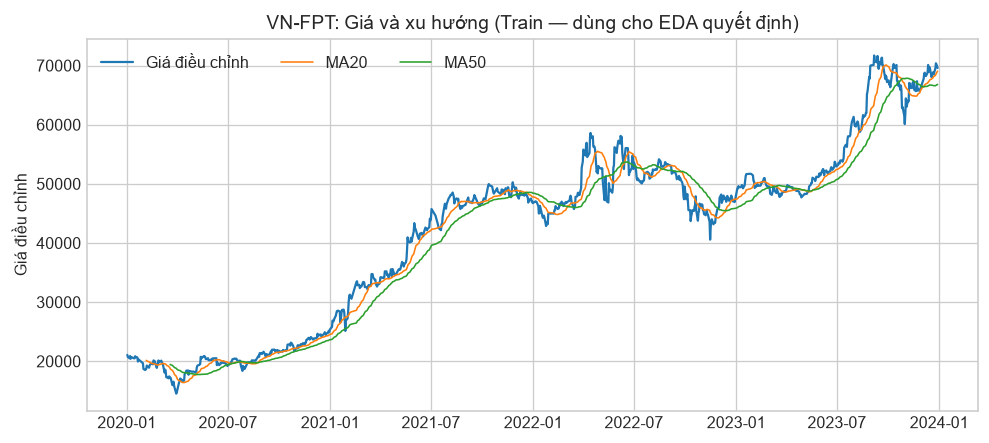

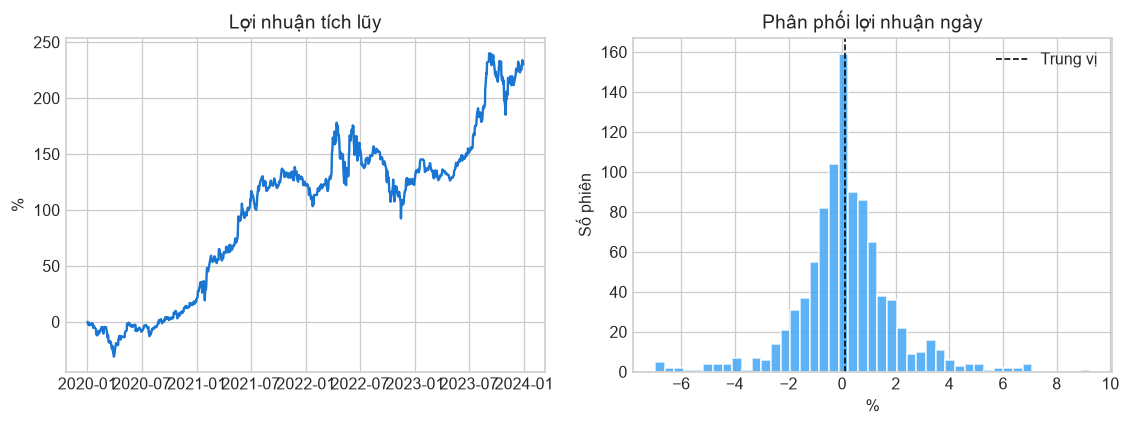

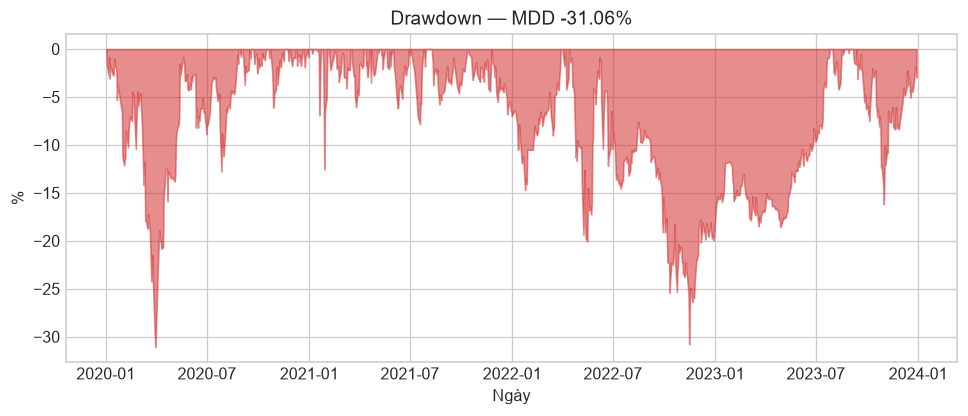

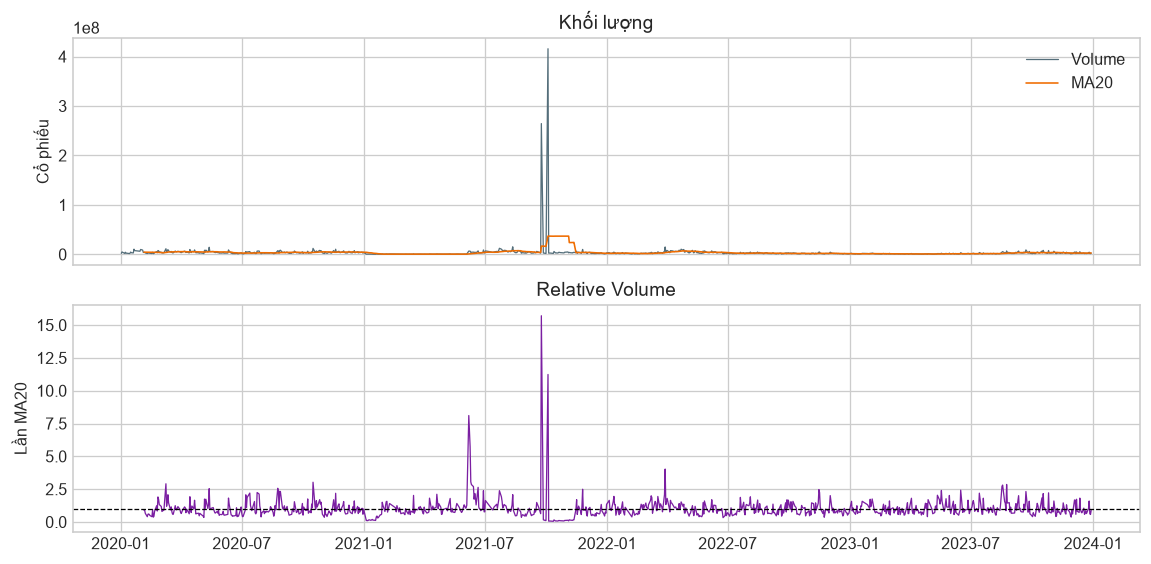

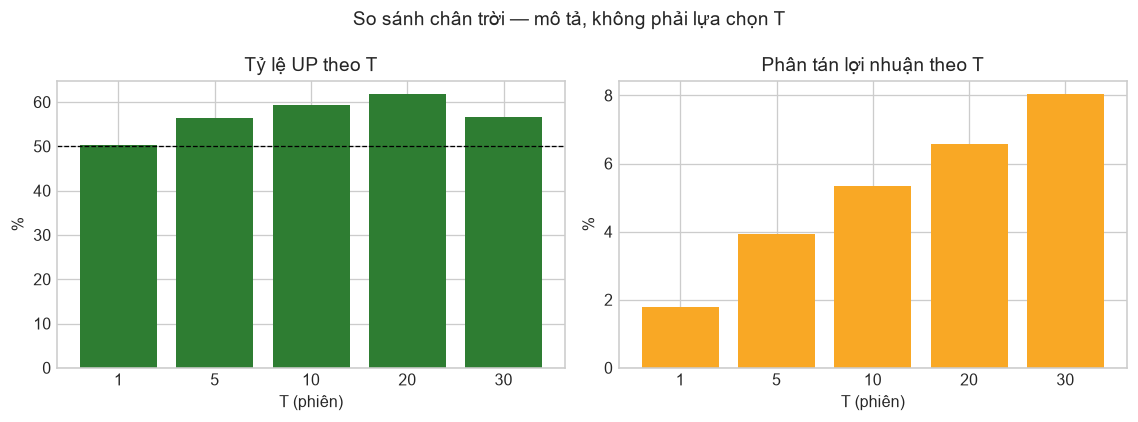

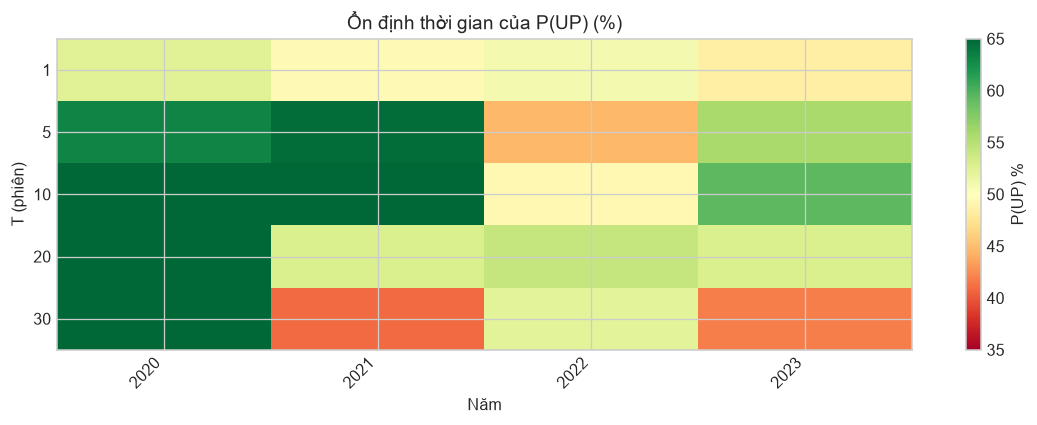

In [10]:
if selected is not None:
    print(f"{selected['market']}-{selected['ticker']} | {selected['scope_label']}")
    display(selected["quality"])
    display(selected["eda"].groupby("Nhóm", as_index=False).first()[["Nhóm", "Chỉ tiêu", "N", "Trung bình", "Trung vị"]])
    display(selected["horizon"])
    display(selected["stability"].head(15))
    display(selected["insights"])
    for key, path in selected["charts"].items():
        display(Image(filename=str(path), width=820))

## 10. Tổng hợp thị trường và so sánh chéo

Tổng hợp báo cáo đồng thời:

- **Trọng số đều công ty:** trung bình statistic của mỗi công ty, mỗi công ty có trọng số như nhau.
- **Trọng số quan sát:** statistic công ty được cân theo số nhãn hợp lệ.

So sánh chỉ dùng lợi nhuận/tỷ lệ, không dùng giá danh nghĩa. Khác biệt coverage được báo cáo riêng. Kết quả US không tự động quyết định T cho VN.


In [11]:
if RESULTS:
    COMPANY_HORIZONS, MARKET_SUMMARIES, CROSS_MARKET, COVERAGE = build_market_summaries(RESULTS)
    display(COVERAGE)
    print("Tóm tắt VN")
    display(MARKET_SUMMARIES["VN"])
    print("Tóm tắt US")
    display(MARKET_SUMMARIES["US"])
    print("So sánh chéo — chỉ mô tả, không chọn T")
    display(CROSS_MARKET)
else:
    print("Không có kết quả thành công để tổng hợp.")

,Thị trường,Số công ty có Train,Ngày bắt đầu sớm nhất,Ngày bắt đầu chung muộn nhất,Ngày kết thúc chung sớm nhất,Ngày kết thúc muộn nhất
0,VN,29,2020-01-02,2021-03-24,2023-12-29,2023-12-29
1,US,20,2020-01-02,2020-01-02,2023-12-29,2023-12-29


Tóm tắt VN


,T,Số công ty,Tổng quan sát,Mean return — trọng số đều công ty,P(UP) — trọng số đều công ty,Mean return — trọng số quan sát,P(UP) — trọng số quan sát
0,1,29,25370,0.0007,0.4756,0.0007,0.4755
1,5,29,21083,0.0027,0.5082,0.0026,0.5081
2,10,29,16769,0.0043,0.5080,0.0040,0.5071
3,20,29,10590,0.0131,0.5287,0.0130,0.5282
4,30,29,7098,0.0184,0.5519,0.0183,0.5521


Tóm tắt US


,T,Số công ty,Tổng quan sát,Mean return — trọng số đều công ty,P(UP) — trọng số đều công ty,Mean return — trọng số quan sát,P(UP) — trọng số quan sát
0,1,20,20100,0.0011,0.5232,0.0011,0.5232
1,5,20,20020,0.0052,0.5521,0.0052,0.5521
2,10,20,19920,0.0103,0.5709,0.0103,0.5709
3,20,20,19720,0.0202,0.5846,0.0202,0.5846
4,30,20,19520,0.0296,0.5918,0.0296,0.5918


So sánh chéo — chỉ mô tả, không chọn T


,T,Số công ty — VN,Tổng quan sát — VN,Mean return — trọng số đều công ty — VN,P(UP) — trọng số đều công ty — VN,Mean return — trọng số quan sát — VN,P(UP) — trọng số quan sát — VN,Số công ty — US,Tổng quan sát — US,Mean return — trọng số đều công ty — US,P(UP) — trọng số đều công ty — US,Mean return — trọng số quan sát — US,P(UP) — trọng số quan sát — US
0,1,29,25370,0.0007,0.4756,0.0007,0.4755,20,20100,0.0011,0.5232,0.0011,0.5232
1,5,29,21083,0.0027,0.5082,0.0026,0.5081,20,20020,0.0052,0.5521,0.0052,0.5521
2,10,29,16769,0.0043,0.5080,0.0040,0.5071,20,19920,0.0103,0.5709,0.0103,0.5709
3,20,29,10590,0.0131,0.5287,0.0130,0.5282,20,19720,0.0202,0.5846,0.0202,0.5846
4,30,29,7098,0.0184,0.5519,0.0183,0.5521,20,19520,0.0296,0.5918,0.0296,0.5918


## 11. Kiểm tra nhất quán đầu ra

Test cuối kiểm tra tệp Excel mở được, đủ sheet bắt buộc, công thức/insight single và đối tượng batch là cùng một kết quả, đồng thời xác minh dữ liệu theo thứ tự thời gian.


In [12]:
from openpyxl import load_workbook

FINAL_TESTS = []
def final_check(name, condition, detail=""):
    FINAL_TESTS.append({"Kiểm thử": name, "Kết quả": "PASS" if bool(condition) else "FAIL", "Chi tiết": detail})

final_check("Tất cả dữ liệu sạch tăng theo thời gian", all(r["data"]["Date"].is_monotonic_increasing for r in RESULTS))
final_check("Không trùng ngày sau làm sạch", all(not r["data"]["Date"].duplicated().any() for r in RESULTS))
final_check("Không có giá không dương sau làm sạch", all(not (r["data"][["Open","High","Low","Close","Adj Close"]] <= 0).any().any() for r in RESULTS))
final_check("Không còn Volume <= 0 sau làm sạch", all((r["data"]["Volume"] > 0).all() for r in RESULTS))

if SINGLE_PATH:
    wb = load_workbook(SINGLE_PATH, read_only=True, data_only=True)
    final_check("Workbook single mở được", len(wb.sheetnames) == 1, str(wb.sheetnames)); wb.close()
if BATCH_PATH:
    wb = load_workbook(BATCH_PATH, read_only=True, data_only=True)
    required = {"Overview", "VN_Summary", "US_Summary", "Cross_Market", "Data_Quality", "Processing_Log"}
    final_check("Workbook batch đủ sheet bắt buộc", required.issubset(set(wb.sheetnames)), f"{len(wb.sheetnames)} sheets")
    final_check("Một sheet cho mỗi công ty thành công", len(wb.sheetnames) == 6 + len(RESULTS), f"actual={len(wb.sheetnames)}")
    wb.close()
if CONFIG["RUN_MODE"] == "both" and selected is not None:
    # Single và batch dùng cùng object; xác minh lại phân tích độc lập cho mã đã chọn.
    repeated = analyze_file(selected["path"], selected["market"], selected["ticker"], make_charts=False)
    same_numbers = selected["horizon"].equals(repeated["horizon"]) and selected["eda"].equals(repeated["eda"])
    same_text = selected["insights"].equals(repeated["insights"])
    final_check("Single/batch đồng nhất số liệu", same_numbers)
    final_check("Single/batch đồng nhất insight", same_text)

FINAL_TEST_RESULTS = pd.DataFrame(FINAL_TESTS)
ALL_TEST_RESULTS = pd.concat([TEST_RESULTS, FINAL_TEST_RESULTS], ignore_index=True)
display(ALL_TEST_RESULTS)
print("TỔNG KẾT:", ALL_TEST_RESULTS["Kết quả"].value_counts().to_dict())
assert ALL_TEST_RESULTS["Kết quả"].eq("PASS").all(), "Có kiểm thử cuối thất bại"
print("HOÀN TẤT: Notebook đã chạy tuần tự, Excel đã được mở kiểm tra và mọi test đều PASS.")

,Kiểm thử,Kết quả,Chi tiết
0,Công thức FutureReturn_1,PASS,actual=0.010000
1,T quan sát cuối là NaN,PASS,
2,Không có nhãn vượt biên split,PASS,
3,Khoảng thiếu phiên bị loại,PASS,
4,Đặc trưng không nhìn tương lai,PASS,
5,Tên worksheet ≤31 ký tự,PASS,
6,Xác suất UP/DOWN cộng 1,PASS,
7,Tất cả dữ liệu sạch tăng theo thời gian,PASS,
8,Không trùng ngày sau làm sạch,PASS,
9,Không có giá không dương sau làm sạch,PASS,


TỔNG KẾT: {'PASS': 16}
HOÀN TẤT: Notebook đã chạy tuần tự, Excel đã được mở kiểm tra và mọi test đều PASS.
